# Step 5 — Stylometric Analysis

Compares the writing style of **real**, **prompt-generated**, and **fine-tuned** messages
per user across a set of quantitative style features.

**Inputs:** `prompt_results.csv` and `finetuned_results.csv` (from notebooks 2A and 2B)

**Outputs:**
- `stylometric_features.csv` — raw feature values for every message
- `stylometric_summary.csv` — per-user, per-model averages for every feature
- `stylometric_distance.csv` — how far each model's style is from the real messages per user
- Visualisations comparing real vs. generated style distributions

**Features extracted:**
- Surface: message length, punctuation rates, capitalisation
- Lexical: TTR / MATTR, function words, slang/filler words, contractions
- Structural: question rate, fragment rate, word repetition, character elongation, emoji rate

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install Dependencies

In [3]:
!pip install -q pandas numpy scipy matplotlib seaborn nltk

## 3. Configuration

In [40]:
# Input files
PROMPT_RESULTS_PATH    = 'few_shot_prompt_results.csv'
FINETUNED_RESULTS_PATH = 'combined_finetuned_results.csv'

# Output directory
OUTPUT_DIR = 'stylometrics'

# MATTR window size (Moving Average TTR — more stable than plain TTR for short texts)
# Decrease if your messages are very short (e.g. 20) - default was 30
MATTR_WINDOW = 15 #I lowered this to 15

# Optional: restrict analysis to specific users. Leave empty to include all.
USERS_TO_INCLUDE = ['U01', 'U03', 'U09', 'U11', 'U12', 'U14']

## 4. Imports

In [41]:
import re
import os
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.spatial.distance import euclidean
from scipy.stats import mannwhitneyu
import nltk

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
COLOURS = {
    'real'               : '#2E86AB',
    'prompt_generated'   : '#E84855',
    'finetuned_generated': '#3BB273',
}
LABELS = {
    'real'               : 'Real',
    'prompt_generated'   : 'Prompt-only',
    'finetuned_generated': 'Fine-tuned',
}
print('Imports done.')

Imports done.


## 5. Load Data

In [42]:
def load_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    return df

prompt_df    = load_csv(PROMPT_RESULTS_PATH)
finetuned_df = load_csv(FINETUNED_RESULTS_PATH)

# Build a unified dataframe with three message types per row pair
# Columns expected: user_id, incoming, ground_truth, generated_reply
def make_pool(df, message_col, message_type):
    return df[['user_id', 'incoming', message_col]].rename(
        columns={message_col: 'text'}
    ).assign(message_type=message_type).dropna(subset=['text'])

all_messages = pd.concat([
    make_pool(prompt_df,    'ground_truth',    'real'),
    make_pool(prompt_df,    'generated_reply', 'prompt_generated'),
    make_pool(finetuned_df, 'generated_reply', 'finetuned_generated'),
], ignore_index=True)

# Filter to requested users
if USERS_TO_INCLUDE:
    all_messages = all_messages[all_messages['user_id'].isin(USERS_TO_INCLUDE)]

users = all_messages['user_id'].unique().tolist()

print(f'Total messages : {len(all_messages)}')
print(f'Users          : {users}')
print(f'\nMessages per type:')
print(all_messages['message_type'].value_counts())

Total messages : 450
Users          : ['U01', 'U03', 'U09', 'U11', 'U12', 'U14']

Messages per type:
message_type
real                   150
prompt_generated       150
finetuned_generated    150
Name: count, dtype: int64


## 6. Feature Extraction

Each function takes a single message string and returns a scalar feature value.

In [59]:
## I have edited below to adapt this to predominantly Spanish text
# ── Word lists ────────────────────────────────────────────────────────────────

# Common texting slang and filler words — strong individual style markers
# en_SLANG = {
#     'lol', 'lmao', 'lmfao', 'omg', 'omfg', 'tbh', 'ngl', 'idk',
#     'imo', 'imho', 'irl', 'smh', 'btw', 'fyi', 'rn', 'af', 'fr',
#     'brb', 'bff', 'wtf', 'rofl', 'ikr', 'ugh', 'meh', 'yikes',
#     'haha', 'hahaha', 'hehe', 'lmk', 'nvm', 'istg', 'ong'
# }

SLANG = {
    'gpi', 'tkm', 'tqm', 'ntp', 'npn', 'pti', 'mdi', 'fds',
    'tlj', 'tqi', 'tki', 'cdt', 'bn', 'pq', 'pk', 'xk', 'xq',
    'xfa', 'tb', 'bs', 'kn', 'klk', 'cnt', 'maso', 'msj', 'nde',
    'mna', 'atte', 'aki', 'vdd', 'gnl', 'mxo', 'kacs', 'ntnc', 'tons', 'aka'
}

# Common informal contractions found in texting
# en_CONTRACTIONS = {
#     "ain't", "aren't", "can't", "couldn't", "didn't", "doesn't",
#     "don't", "hadn't", "hasn't", "haven't", "he'd", "he'll", "he's",
#     "i'd", "i'll", "i'm", "i've", "isn't", "it's", "let's", "she'd",
#     "she'll", "she's", "shouldn't", "that's", "there's", "they'd",
#     "they'll", "they're", "they've", "wasn't", "we'd", "we'll",
#     "we're", "we've", "weren't", "what's", "where's", "who's",
#     "won't", "wouldn't", "you'd", "you'll", "you're", "you've",
#     "gonna", "wanna", "gotta", "kinda", "sorta", "lemme", "gimme"
# }

CONTRACTIONS = {
    "pa", "paque", "pati", "padentro", "paca", "ta", "tas", "toy",
    "tabamos", "pal", "onde", "ondes", "ontas"
}

# High-frequency function words that are author-specific
FUNCTION_WORDS = {
    'literalmente',
    'basicamente', 'honestamente', 'probablemente', 'definitivamente',
    'totalmente', 'bastante', 'aunque', 'tambien', 'okay', 'ok', "[EMO"
}

ELONGATION_PATTERN = re.compile(r'(.)\1{2,}')  # 3+ repeated characters
ELLIPSIS_PATTERN   = re.compile(r'\.{2,}')

print('Word lists and patterns ready.')

Word lists and patterns ready.


In [60]:
# ── Feature functions ─────────────────────────────────────────────────────────

def tokenize(text):
    """Lowercase word tokens, no punctuation."""
    return re.findall(r"[a-z']+", text.lower())


# — Surface features —

def char_length(text):
    return len(text)

def word_count(text):
    return len(tokenize(text))

def avg_word_length(text):
    words = [w for w in tokenize(text) if w.isalpha()]
    return np.mean([len(w) for w in words]) if words else 0.0

def exclamation_rate(text):
    """Exclamation marks per message."""
    return text.count('!')

def question_mark_rate(text):
    return text.count('?')

def es_exclamation_rate(text):
    """Exclamation marks per message."""
    return text.count('¡')

def es_question_mark_rate(text):
    return text.count('¿')

def ellipsis_rate(text):
    return len(ELLIPSIS_PATTERN.findall(text))

def ends_with_punctuation(text):
    """1 if message ends with . ! or ?, else 0."""
    stripped = text.strip()
    return 1.0 if stripped and stripped[-1] in '.!?' else 0.0

def starts_with_punctuation(text):
    """1 if message ends with . ! or ?, else 0."""
    stripped = text.strip()
    return 1.0 if stripped and stripped[-1] in '¡¿' else 0.0

def uppercase_ratio(text):
    """Ratio of uppercase letters to all letters."""
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def all_lowercase(text):
    """1 if no uppercase letters at all."""
    return 1.0 if text == text.lower() else 0.0


# — Lexical features —

def ttr(text):
    """Type-Token Ratio — unique words / total words."""
    words = tokenize(text)
    if len(words) < 2:
        return 1.0
    return len(set(words)) / len(words)

def mattr(text, window=MATTR_WINDOW):
    """
    Moving Average TTR — more stable than plain TTR for short texts.
    Falls back to plain TTR if the message is shorter than the window.
    """
    words = tokenize(text)
    if len(words) < window:
        return ttr(text)
    ttrs = [
        len(set(words[i:i+window])) / window
        for i in range(len(words) - window + 1)
    ]
    return np.mean(ttrs)

def slang_rate(text):
    """Slang/filler words per message."""
    words = tokenize(text)
    return sum(1 for w in words if w in SLANG)

def contraction_rate(text):
    """Contractions per message."""
    words = tokenize(text)
    return sum(1 for w in words if w in CONTRACTIONS)

def function_word_rate(text):
    """Function words per message."""
    words = tokenize(text)
    return sum(1 for w in words if w in FUNCTION_WORDS)


# — Structural features —

def has_question(text):
    """1 if message contains a question mark."""
    return 1.0 if '?' in text else 0.0

def is_fragment(text):
    """
    Heuristic: message is a fragment if it is < 4 words and
    does not end with sentence-ending punctuation.
    """
    words = tokenize(text)
    return 1.0 if len(words) < 4 and not ends_with_punctuation(text) else 0.0

def elongation_count(text):
    """Number of elongated words (e.g. 'yesssss', 'noooo')."""
    return len(ELONGATION_PATTERN.findall(text))

def word_repetition(text):
    """
    Count of consecutive repeated words (e.g. 'so so', 'yeah yeah').
    """
    words = tokenize(text)
    return sum(1 for i in range(1, len(words)) if words[i] == words[i-1])

def reply_length_ratio(text, incoming):
    """Ratio of reply word count to incoming word count."""
    inc_words = len(tokenize(incoming)) if isinstance(incoming, str) else 1
    rep_words = len(tokenize(text))
    return rep_words / max(inc_words, 1)


# ── Master feature extraction ─────────────────────────────────────────────────

FEATURES = [
    # (feature_name, function, needs_incoming)
    ('char_length',          char_length,          False),
    ('word_count',           word_count,            False),
    ('avg_word_length',      avg_word_length,       False),
    ('exclamation_rate',     exclamation_rate,      False),
    ('question_mark_rate',   question_mark_rate,    False),
    ('es_exclamation_rate',  es_exclamation_rate,   False),
    ('es_question_mark_rate', es_question_mark_rate,False),
    ('ellipsis_rate',        ellipsis_rate,         False),
    ('ends_with_punctuation', ends_with_punctuation, False),
    ('starts_with_punctuation', starts_with_punctuation, False),
    ('uppercase_ratio',      uppercase_ratio,       False),
    ('all_lowercase',        all_lowercase,         False),
    ('mattr',                mattr,                 False),
    ('slang_rate',           slang_rate,            False),
    ('contraction_rate',     contraction_rate,      False),
    ('function_word_rate',   function_word_rate,    False),
    ('has_question',         has_question,          False),
    ('is_fragment',          is_fragment,           False),
    ('elongation_count',     elongation_count,      False),
    ('word_repetition',      word_repetition,       False),
    ('reply_length_ratio',   reply_length_ratio,    True),
]

FEATURE_NAMES = [f[0] for f in FEATURES]

print(f'{len(FEATURES)} features defined.')

21 features defined.


In [61]:
# ── Apply to every message ────────────────────────────────────────────────────

def extract_features(row):
    text     = str(row['text'])
    incoming = str(row['incoming']) if pd.notna(row['incoming']) else ''
    result   = {}
    for name, fn, needs_incoming in FEATURES:
        try:
            result[name] = fn(text, incoming) if needs_incoming else fn(text)
        except Exception:
            result[name] = np.nan
    return pd.Series(result)

print('Extracting features...')
feature_df = all_messages.copy()
feature_values = feature_df.apply(extract_features, axis=1)
feature_df = pd.concat([feature_df, feature_values], axis=1)

# Save raw features
raw_path = os.path.join(OUTPUT_DIR, 'stylometric_features.csv')
feature_df.to_csv(raw_path, index=False)

print(f'Extracted {len(FEATURE_NAMES)} features for {len(feature_df)} messages.')
print(f'Saved -> {raw_path}')
feature_df.head(3)

Extracting features...
Extracted 21 features for 450 messages.
Saved -> /content/drive/MyDrive/llm_project/results/stylometrics/stylometric_features.csv


,user_id,incoming,text,message_type,char_length,word_count,avg_word_length,exclamation_rate,question_mark_rate,es_exclamation_rate,...,all_lowercase,mattr,slang_rate,contraction_rate,function_word_rate,has_question,is_fragment,elongation_count,word_repetition,reply_length_ratio
0,U01,"Holiiiii, Ne contajiaste el Holiiii",Jajajaja sii el holii es contajiosos jaja,real,41.0,7.0,5.000000,0.0,0.0,0.0,...,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.400000
1,U01,Waaoooo pense que ibas a dormir,No voy al culto jaja y de ahi a seguir estudiando,real,49.0,11.0,3.545455,0.0,0.0,0.0,...,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.833333
2,U01,"Hoodoo sorry ok., Hola mi preciosa","Hola Pa, Pa estoy con.la.[NAME, 5] en.un conci...",real,60.0,11.0,4.000000,0.0,0.0,0.0,...,0.0,0.909091,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.833333


## 7. Per-User Summary Statistics

In [62]:
# Mean of each feature grouped by user and message type
summary = (
    feature_df
    .groupby(['user_id', 'message_type'])[FEATURE_NAMES]
    .mean()
    .round(4)
    .reset_index()
)

summary_path = os.path.join(OUTPUT_DIR, 'stylometric_summary.csv')
summary.to_csv(summary_path, index=False)

print(f'Summary saved -> {summary_path}')
print(f'\nSample — first user, all three message types:')
sample_user = users[0]
display_cols = ['message_type'] + FEATURE_NAMES[:8]
summary[summary['user_id'] == sample_user][display_cols].set_index('message_type')

Summary saved -> /content/drive/MyDrive/llm_project/results/stylometrics/stylometric_summary.csv

Sample — first user, all three message types:


,char_length,word_count,avg_word_length,exclamation_rate,question_mark_rate,es_exclamation_rate,es_question_mark_rate,ellipsis_rate
message_type,,,,,,,,
finetuned_generated,51.4167,9.1111,10.7719,0.0000,0.1667,0.0000,0.0000,0.0000
prompt_generated,36.3611,6.6944,4.3774,0.3889,0.1389,0.1667,0.1389,0.0000
real,68.4444,13.2500,3.9353,0.0000,0.1389,0.0000,0.0000,0.0278


## 8. Style Distance Score

For each user and each model (prompt / fine-tuned), compute the Euclidean distance
between its feature vector and the real messages' feature vector.

A **lower distance = closer to the real person's style**.

Features are z-score normalised before computing distance so no single
feature (e.g. char_length) dominates just because it has larger values.

In [63]:
from scipy.stats import zscore

# Normalise features globally so they are on the same scale
norm_df = feature_df.copy()
norm_df[FEATURE_NAMES] = feature_df[FEATURE_NAMES].apply(zscore, nan_policy='omit')

distance_rows = []

for user_id in users:
    user_norm = norm_df[norm_df['user_id'] == user_id]

    real_vec = (
        user_norm[user_norm['message_type'] == 'real'][FEATURE_NAMES]
        .mean()
        .fillna(0)
        .values
    )

    for msg_type in ['prompt_generated', 'finetuned_generated']:
        model_vec = (
            user_norm[user_norm['message_type'] == msg_type][FEATURE_NAMES]
            .mean()
            .fillna(0)
            .values
        )
        dist = euclidean(real_vec, model_vec)
        distance_rows.append({
            'user_id'     : user_id,
            'model'       : LABELS[msg_type],
            'style_distance': round(dist, 4),
        })

distance_df = pd.DataFrame(distance_rows)

dist_path = os.path.join(OUTPUT_DIR, 'stylometric_distance.csv')
distance_df.to_csv(dist_path, index=False)

print('Style distance from real messages (lower = closer to real style):')
print(distance_df.pivot(index='user_id', columns='model', values='style_distance').to_string())
print(f'\nSaved -> {dist_path}')

Style distance from real messages (lower = closer to real style):
model    Fine-tuned  Prompt-only
user_id                         
U01          0.9492       2.2865
U03          2.5513       2.2302
U09          1.2375       1.1737
U11          2.3734       2.1769
U12          2.8927       2.8464
U14          0.8699       1.4277

Saved -> /content/drive/MyDrive/llm_project/results/stylometrics/stylometric_distance.csv


In [64]:
# Calculate distance between the two generated types specifically
gen_comparison_rows = []

for user_id in users:
    user_norm = norm_df[norm_df['user_id'] == user_id]

    # Get vectors for both generation methods
    prompt_vec = (
        user_norm[user_norm['message_type'] == 'prompt_generated'][FEATURE_NAMES]
        .mean().fillna(0).values
    )

    finetune_vec = (
        user_norm[user_norm['message_type'] == 'finetuned_generated'][FEATURE_NAMES]
        .mean().fillna(0).values
    )

    # Calculate Euclidean distance between the two model outputs
    dist_between_models = euclidean(prompt_vec, finetune_vec)

    gen_comparison_rows.append({
        'user_id': user_id,
        'prompt_vs_finetuned_dist': round(dist_between_models, 4)
    })

# Create and display the comparison dataframe
gen_distance_df = pd.DataFrame(gen_comparison_rows)

print('\nEuclidean distance between Prompt-based and Finetuned results:')
print(gen_distance_df.to_string(index=False))

# Optional: Save to CSV
gen_dist_path = os.path.join(OUTPUT_DIR, 'model_comparison_distance.csv')
gen_distance_df.to_csv(gen_dist_path, index=False)


Euclidean distance between Prompt-based and Finetuned results:
user_id  prompt_vs_finetuned_dist
    U01                    1.9089
    U03                    2.4830
    U09                    2.1931
    U11                    2.6971
    U12                    3.6070
    U14                    1.4299


## 9. Statistical Significance Tests

For each feature and each user, run a Mann-Whitney U test comparing the real
message distribution against each model's distribution.

Mann-Whitney is used instead of a t-test because text feature distributions
are rarely normal — especially for count features like emoji or slang rate.

A significant result (p < 0.05) means the model's distribution for that
feature is statistically different from the real person's.

In [65]:
sig_rows = []

for user_id in users:
    user_df = feature_df[feature_df['user_id'] == user_id]
    real_data = user_df[user_df['message_type'] == 'real']

    for msg_type in ['prompt_generated', 'finetuned_generated']:
        model_data = user_df[user_df['message_type'] == msg_type]

        for feat in FEATURE_NAMES:
            real_vals  = real_data[feat].dropna().values
            model_vals = model_data[feat].dropna().values

            if len(real_vals) < 3 or len(model_vals) < 3:
                continue

            # Skip if all values are identical (test would be undefined)
            if np.all(real_vals == real_vals[0]) and np.all(model_vals == model_vals[0]):
                continue

            try:
                stat, p = mannwhitneyu(real_vals, model_vals, alternative='two-sided')
            except ValueError:
                continue

            sig_rows.append({
                'user_id'     : user_id,
                'model'       : LABELS[msg_type],
                'feature'     : feat,
                'real_mean'   : round(real_vals.mean(), 4),
                'model_mean'  : round(model_vals.mean(), 4),
                'difference'  : round(model_vals.mean() - real_vals.mean(), 4),
                'p_value'     : round(p, 4),
                'significant' : p < 0.05,
            })

sig_df = pd.DataFrame(sig_rows)
sig_path = os.path.join(OUTPUT_DIR, 'significance_tests.csv')
sig_df.to_csv(sig_path, index=False)

print('Features with significant differences from real (p < 0.05):')
sig_only = sig_df[sig_df['significant']].sort_values(['user_id', 'model', 'p_value'])
print(sig_only[['user_id', 'model', 'feature', 'real_mean', 'model_mean', 'difference', 'p_value']].to_string(index=False))
print(f'\nSaved -> {sig_path}')

Features with significant differences from real (p < 0.05):
user_id       model               feature  real_mean  model_mean  difference  p_value
    U01  Fine-tuned           char_length    68.4444     51.4167    -17.0278   0.0104
    U01  Fine-tuned            word_count    13.2500      9.1111     -4.1389   0.0172
    U01 Prompt-only            word_count    13.2500      6.6944     -6.5556   0.0001
    U01 Prompt-only ends_with_punctuation     0.1111      0.5556      0.4444   0.0001
    U01 Prompt-only           char_length    68.4444     36.3611    -32.0833   0.0004
    U01 Prompt-only      exclamation_rate     0.0000      0.3889      0.3889   0.0004
    U01 Prompt-only    reply_length_ratio     2.8265      1.0056     -1.8209   0.0097
    U01 Prompt-only   es_exclamation_rate     0.0000      0.1667      0.1667   0.0114
    U01 Prompt-only es_question_mark_rate     0.0000      0.1389      0.1389   0.0221
    U01 Prompt-only      contraction_rate     0.1944      0.0000     -0.1944   0

## 10. Visualisations

Three plots:
1. **Style distance bar chart** — which model is closer to each user's real style overall
2. **Feature heatmap** — per-user deviation of each model from real, per feature
3. **Distribution plots** — per-feature violin plots across all users

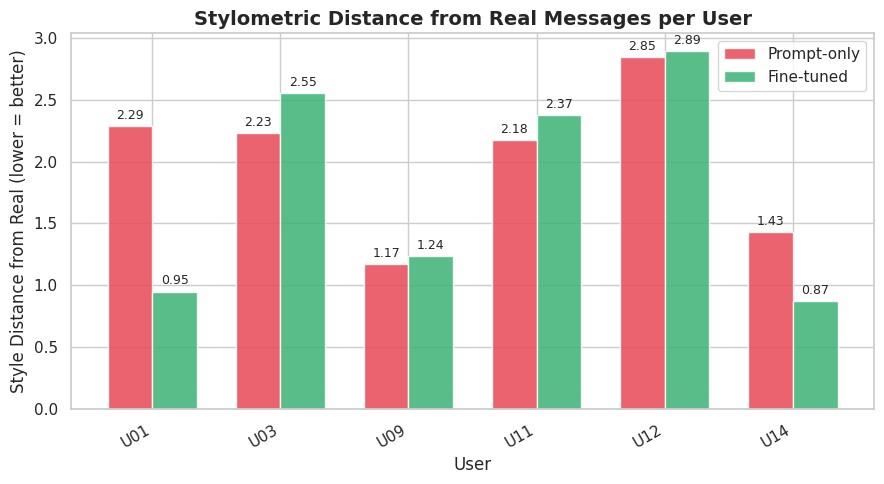

Saved -> /content/drive/MyDrive/llm_project/results/stylometrics/plot_style_distance.png


In [66]:
# ── Plot 1: Style distance bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(users) * 1.5), 5))

pivot = distance_df.pivot(index='user_id', columns='model', values='style_distance')
x     = np.arange(len(pivot))
width = 0.35

bars_p = ax.bar(x - width/2, pivot['Prompt-only'],  width, label='Prompt-only',  color=COLOURS['prompt_generated'],    alpha=0.85)
bars_f = ax.bar(x + width/2, pivot['Fine-tuned'],   width, label='Fine-tuned',   color=COLOURS['finetuned_generated'], alpha=0.85)

ax.set_xlabel('User', fontsize=12)
ax.set_ylabel('Style Distance from Real (lower = better)', fontsize=12)
ax.set_title('Stylometric Distance from Real Messages per User', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.legend()
ax.bar_label(bars_p, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars_f, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()

dist_plot_path = os.path.join(OUTPUT_DIR, 'plot_style_distance.png')
plt.savefig(dist_plot_path, dpi=150)
plt.show()
print(f'Saved -> {dist_plot_path}')

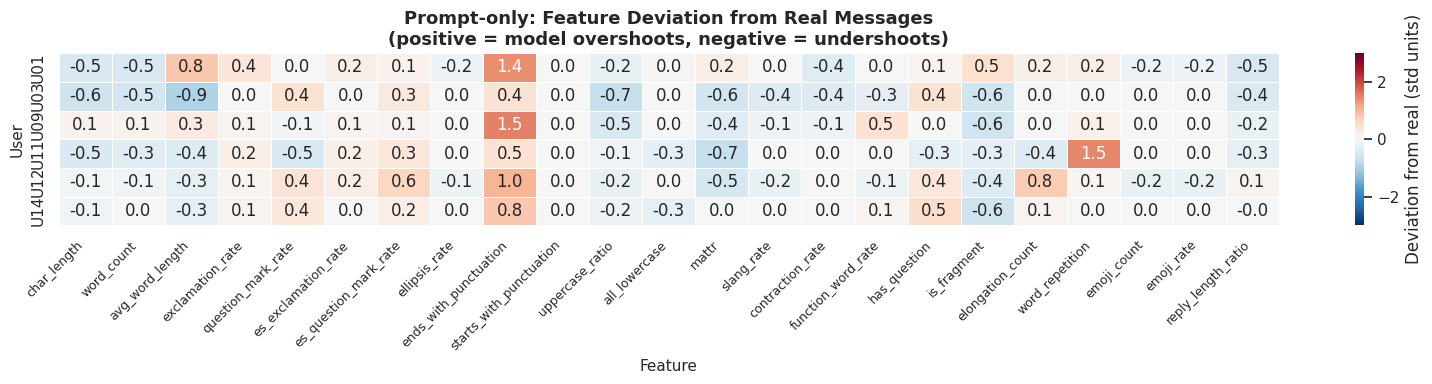

Saved -> /content/drive/MyDrive/llm_project/results/stylometrics/plot_heatmap_prompt_generated.png


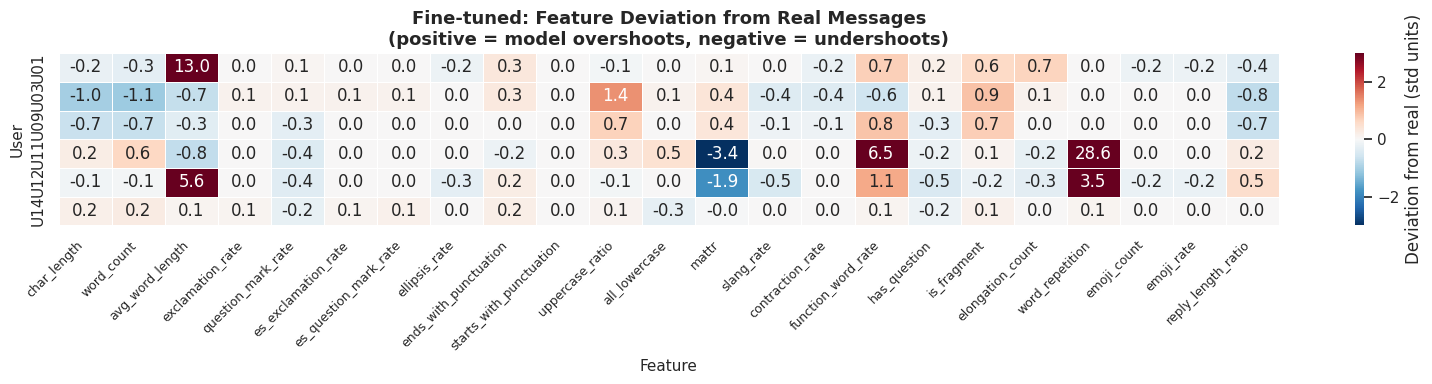

Saved -> /content/drive/MyDrive/llm_project/results/stylometrics/plot_heatmap_finetuned_generated.png


In [29]:
# ── Plot 2: Feature deviation heatmap ────────────────────────────────────────
# For each user x feature, compute: model_mean - real_mean (normalised)
# Positive = model overshoots, Negative = undershoots

for msg_type in ['prompt_generated', 'finetuned_generated']:
    heatmap_data = []

    for user_id in users:
        user_df    = feature_df[feature_df['user_id'] == user_id]
        real_means = user_df[user_df['message_type'] == 'real'][FEATURE_NAMES].mean()
        model_means= user_df[user_df['message_type'] == msg_type][FEATURE_NAMES].mean()
        # Normalise difference by real std to get a dimensionless deviation
        real_std   = user_df[user_df['message_type'] == 'real'][FEATURE_NAMES].std().replace(0, 1)
        deviation  = ((model_means - real_means) / real_std).round(2)
        heatmap_data.append(deviation)

    heatmap_df = pd.DataFrame(heatmap_data, index=users, columns=FEATURE_NAMES)

    fig, ax = plt.subplots(figsize=(max(14, len(FEATURE_NAMES) * 0.7), max(4, len(users) * 0.6)))
    sns.heatmap(
        heatmap_df,
        ax=ax,
        cmap='RdBu_r',
        center=0,
        vmin=-3, vmax=3,
        annot=True, fmt='.1f',
        linewidths=0.4,
        cbar_kws={'label': 'Deviation from real (std units)'}
    )
    label = LABELS[msg_type]
    ax.set_title(f'{label}: Feature Deviation from Real Messages\n(positive = model overshoots, negative = undershoots)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature', fontsize=11)
    ax.set_ylabel('User', fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()

    heatmap_path = os.path.join(OUTPUT_DIR, f'plot_heatmap_{msg_type}.png')
    plt.savefig(heatmap_path, dpi=150)
    plt.show()
    print(f'Saved -> {heatmap_path}')

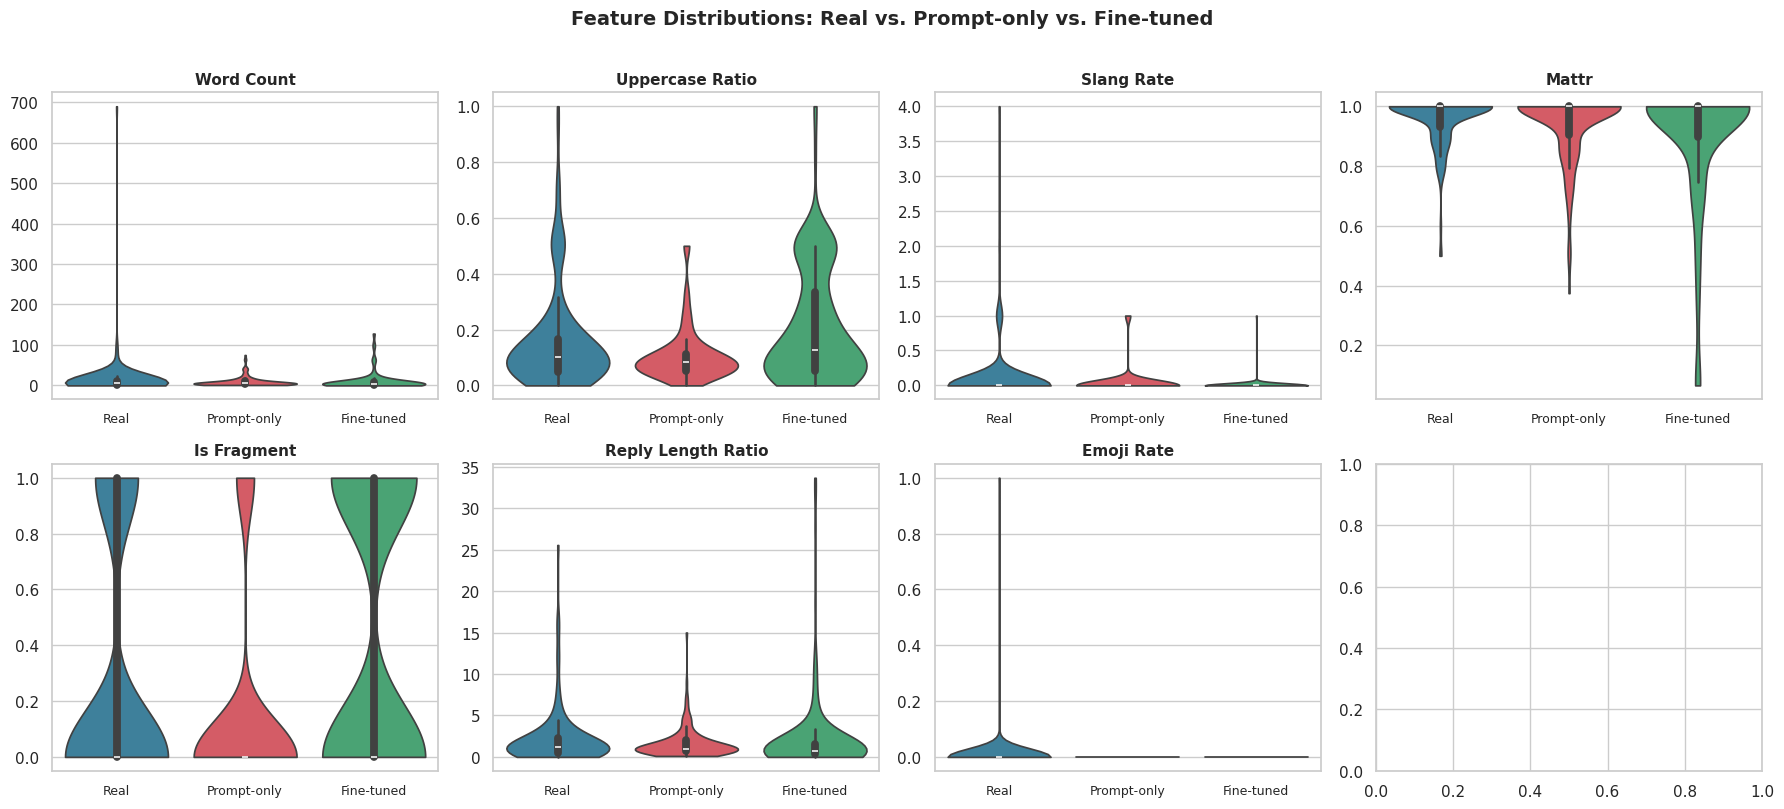

Saved -> /content/drive/MyDrive/llm_project/results/stylometrics/plot_violin_distributions.png


In [30]:
# ── Plot 3: Violin plots for key features ────────────────────────────────────
# Show distribution of each feature across all messages, split by message type

KEY_FEATURES = [
    'word_count', 'uppercase_ratio',
    'slang_rate', 'mattr',
    'is_fragment', 'reply_length_ratio', 'emoji_rate'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_df = feature_df.copy()
plot_df['Model'] = plot_df['message_type'].map(LABELS)
type_order = ['Real', 'Prompt-only', 'Fine-tuned']
palette    = {LABELS[k]: v for k, v in COLOURS.items()}

for i, feat in enumerate(KEY_FEATURES):
    ax = axes[i]
    sns.violinplot(
        data=plot_df,
        x='Model', y=feat,
        order=type_order,
        palette=palette,
        ax=ax,
        inner='box',
        cut=0
    )
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Feature Distributions: Real vs. Prompt-only vs. Fine-tuned', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

violin_path = os.path.join(OUTPUT_DIR, 'plot_violin_distributions.png')
plt.savefig(violin_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {violin_path}')

## 11. Summary Report

Prints a plain-language summary of the key findings per user.

In [14]:
print('=' * 60)
print('  STYLOMETRIC ANALYSIS SUMMARY')
print('=' * 60)

for user_id in users:
    print(f'\n--- User: {user_id} ---')

    user_dist = distance_df[distance_df['user_id'] == user_id].set_index('model')['style_distance']
    prompt_dist   = user_dist.get('Prompt-only', None)
    finetuned_dist= user_dist.get('Fine-tuned', None)

    if prompt_dist is not None and finetuned_dist is not None:
        winner = 'Fine-tuned' if finetuned_dist < prompt_dist else 'Prompt-only'
        print(f'  Overall style distance:')
        print(f'    Prompt-only : {prompt_dist:.3f}')
        print(f'    Fine-tuned  : {finetuned_dist:.3f}')
        print(f'    Closer to real style: {winner}')

    # Most significantly different features
    user_sig = sig_df[
        (sig_df['user_id'] == user_id) & sig_df['significant']
    ].sort_values('p_value')

    if not user_sig.empty:
        print(f'  Top significantly different features (p < 0.05):')
        for _, row in user_sig.head(5).iterrows():
            direction = 'higher' if row['difference'] > 0 else 'lower'
            print(f'    [{row["model"]}] {row["feature"]}: model is {direction} '
                  f'(real={row["real_mean"]:.2f}, model={row["model_mean"]:.2f}, p={row["p_value"]:.3f})')
    else:
        print(f'  No features significantly different from real (p < 0.05)')

print('\n' + '=' * 60)
print('Files saved:')
for fname in [
    'stylometric_features.csv',
    'stylometric_summary.csv',
    'stylometric_distance.csv',
    'significance_tests.csv',
    'plot_style_distance.png',
    'plot_heatmap_prompt_generated.png',
    'plot_heatmap_finetuned_generated.png',
    'plot_violin_distributions.png',
]:
    print(f'  {os.path.join(OUTPUT_DIR, fname)}')

  STYLOMETRIC ANALYSIS SUMMARY

--- User: U01 ---
  Overall style distance:
    Prompt-only : 2.287
    Fine-tuned  : 0.949
    Closer to real style: Fine-tuned
  Top significantly different features (p < 0.05):
    [Prompt-only] word_count: model is lower (real=13.25, model=6.69, p=0.000)
    [Prompt-only] ends_with_punctuation: model is higher (real=0.11, model=0.56, p=0.000)
    [Prompt-only] exclamation_rate: model is higher (real=0.00, model=0.39, p=0.000)
    [Prompt-only] char_length: model is lower (real=68.44, model=36.36, p=0.000)
    [Prompt-only] reply_length_ratio: model is lower (real=2.83, model=1.01, p=0.010)

--- User: U03 ---
  Overall style distance:
    Prompt-only : 2.230
    Fine-tuned  : 2.551
    Closer to real style: Prompt-only
  Top significantly different features (p < 0.05):
    [Fine-tuned] reply_length_ratio: model is lower (real=6.29, model=0.81, p=0.028)
    [Fine-tuned] word_count: model is lower (real=8.86, model=1.71, p=0.036)
    [Fine-tuned] char_l